## Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.


In [1]:
### load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import contingency, chi2_contingency, pearsonr, probplot

%matplotlib inline

In [2]:
### read df from local folder
df = pd.read_csv('amz_uk_price_prediction_dataset.csv')

In [3]:
### take a peek inside
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [4]:
df.shape

(2443651, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 151.5 MB


In [6]:
df.isna().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [7]:
missing = df.isna().sum()
missing = missing[missing > 0]
missing

Series([], dtype: int64)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.eq(' ').sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [10]:
round(df.describe().T, 2)

,count,mean,std,min,25%,50%,75%,max
uid,2443651.0,1370545.35,816056.17,1.0,658921.50,1349029.00,2060685.50,2828593.0
stars,2443651.0,2.15,2.19,0.0,0.00,0.00,4.40,5.0
reviews,2443651.0,480.63,5944.12,0.0,0.00,0.00,59.00,1356658.0
price,2443651.0,89.24,345.61,0.0,9.99,19.09,45.99,100000.0
boughtInLastMonth,2443651.0,25.90,240.48,0.0,0.00,0.00,0.00,50000.0


### Conclusion - clean data !
we split the data in 2, numerical and categorical

In [11]:
cat = df.select_dtypes(exclude="number")
num = df.select_dtypes(include="number")


---

### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.


In [12]:
crosstab_result2 = pd.crosstab(cat['category'], cat['isBestSeller'])
ct = crosstab_result2.copy()

In [13]:
crosstab_result2['Total'] = crosstab_result2[False] + crosstab_result2[True]
crosstab_result2['Proc'] = crosstab_result2[True]*100 / crosstab_result2['Total']
mt = crosstab_result2.sort_values(by='Proc', ascending=False).copy

    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*


"Grocery", "Smart Home Security & Lighting" and "Healt personal care" have the highest prlevance 5%



2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    


In [14]:
crosstab_result = pd.crosstab(cat['category'], cat['isBestSeller'])
contingency_table = (crosstab_result.loc[:, [False, True]] + 1).copy()

chi2_stat, chi2_pvalue, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {chi2_pvalue:.8f}")
print(f"Degrees of freedom: {dof}")

cramers_v = np.sqrt(chi2_stat / (contingency_table.values.sum() * (min(contingency_table.shape) - 1)))
print(f"Cramér's V: {cramers_v:.4f}")

Chi-square statistic: 0.0000
p-value: 1.00000000
Degrees of freedom: 0
Cramér's V: nan


C:\Users\cici\AppData\Local\Temp\ipykernel_12920\1625869136.py:9: RuntimeWarning: invalid value encountered in divide
  cramers_v = np.sqrt(chi2_stat / (contingency_table.values.sum() * (min(contingency_table.shape) - 1)))


    - Compute Cramér's V to understand the strength of association between best-seller status and category.


In [15]:
contingency.association(ct, method='cramer')

0.1222829439760564


3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.


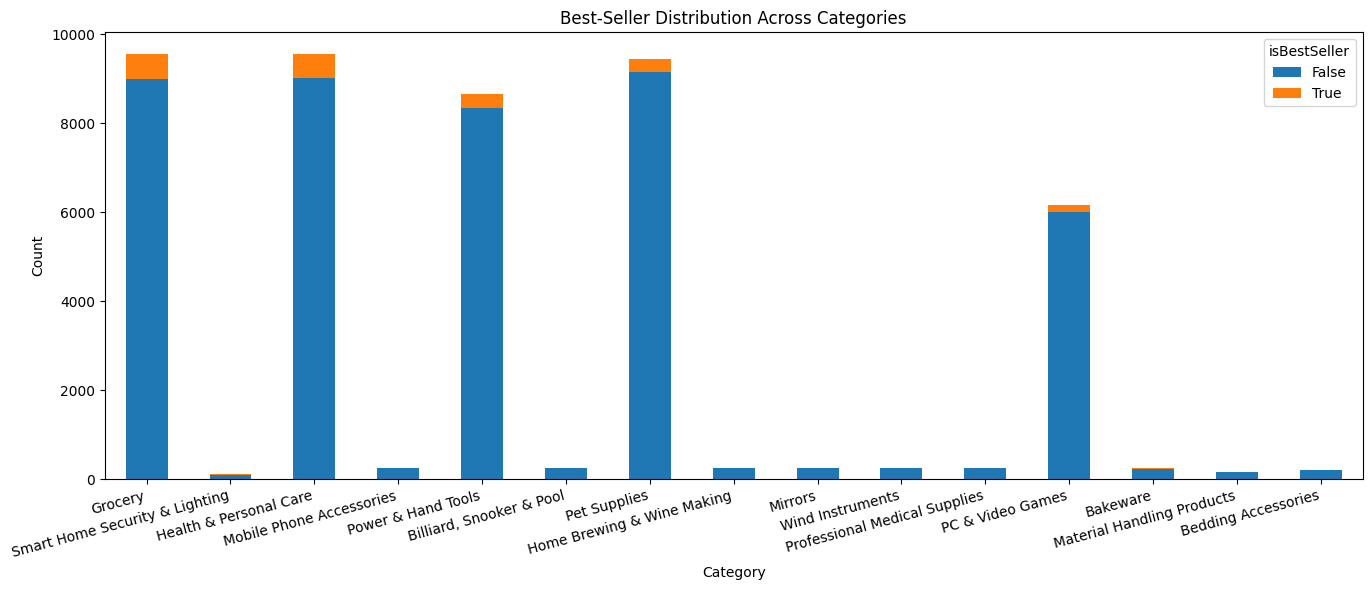

In [16]:
crosstab_result = pd.crosstab(cat['category'], cat['isBestSeller'])
stacked = crosstab_result.copy()
stacked['Total'] = stacked[False] + stacked[True]
stacked['BestSellerPct'] = stacked[True] / stacked['Total']

stacked_top = stacked.sort_values('BestSellerPct', ascending=False).head(15)

stacked_top.iloc[:, :2].plot(kind='bar', stacked=True, figsize=(14, 6))
plt.title('Best-Seller Distribution Across Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


---

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*


In [17]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

print(f"\nOriginal dataset size: {len(df)}")
print(f"Dataset after removing outliers: {len(df_no_outliers)}")
print(f"Number of outliers removed: {len(df) - len(df_no_outliers)}")

Q1: 9.99
Q3: 45.99
IQR: 36.0
Lower bound: -44.01
Upper bound: 99.99000000000001

Original dataset size: 2443651
Dataset after removing outliers: 2115963
Number of outliers removed: 327688



1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    


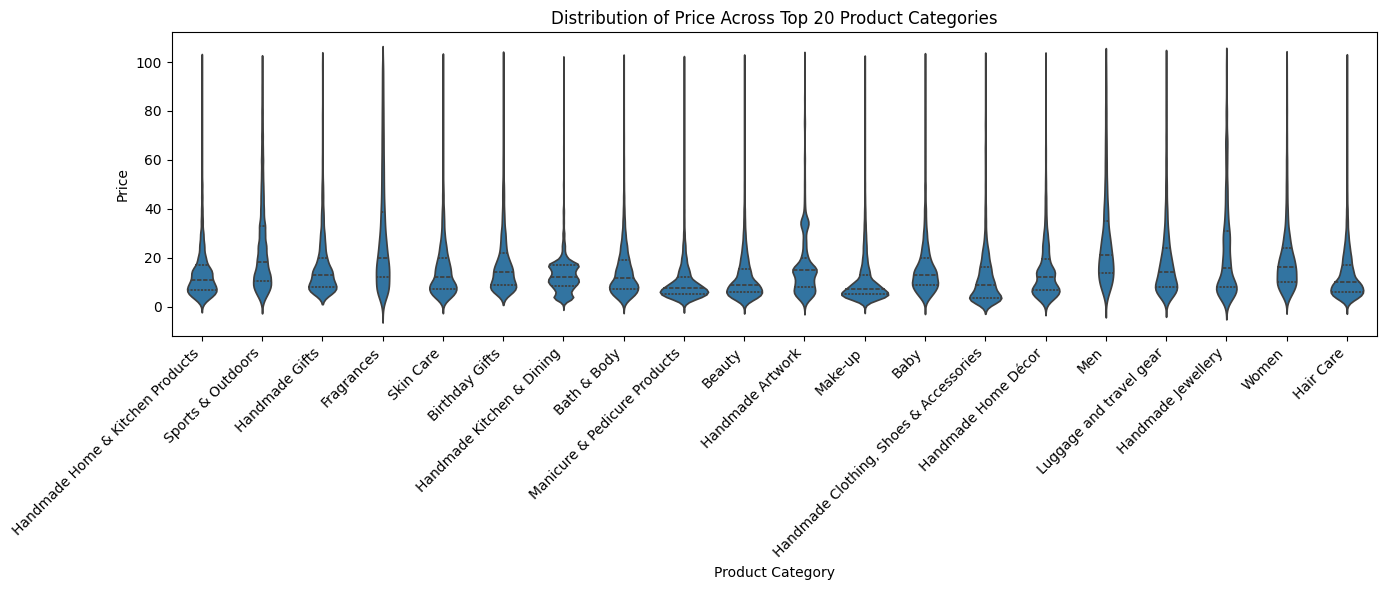

In [18]:
top_20_categories = df_no_outliers['category'].value_counts().head(20).index
df_top_20 = df_no_outliers[df_no_outliers['category'].isin(top_20_categories)]

plt.figure(figsize=(14, 6))
sns.violinplot(data=df_top_20, x='category', y='price', inner='quartile')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Price Across Top 20 Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

    - Which product category tends to have the highest median price? Don't filter here by top categories.

In [19]:
# Find which category has the highest median price (all categories, not filtered)
median_price_by_category = df_no_outliers.groupby('category')['price'].median().sort_values(ascending=False)
print("Top 10 categories by median price:")
print(median_price_by_category.head(10))
print(f"\nCategory with highest median price: {median_price_by_category.index[0]} (£{median_price_by_category.iloc[0]:.2f})")

Top 10 categories by median price:
category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

Category with highest median price: Desktop PCs (£74.00)



2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).


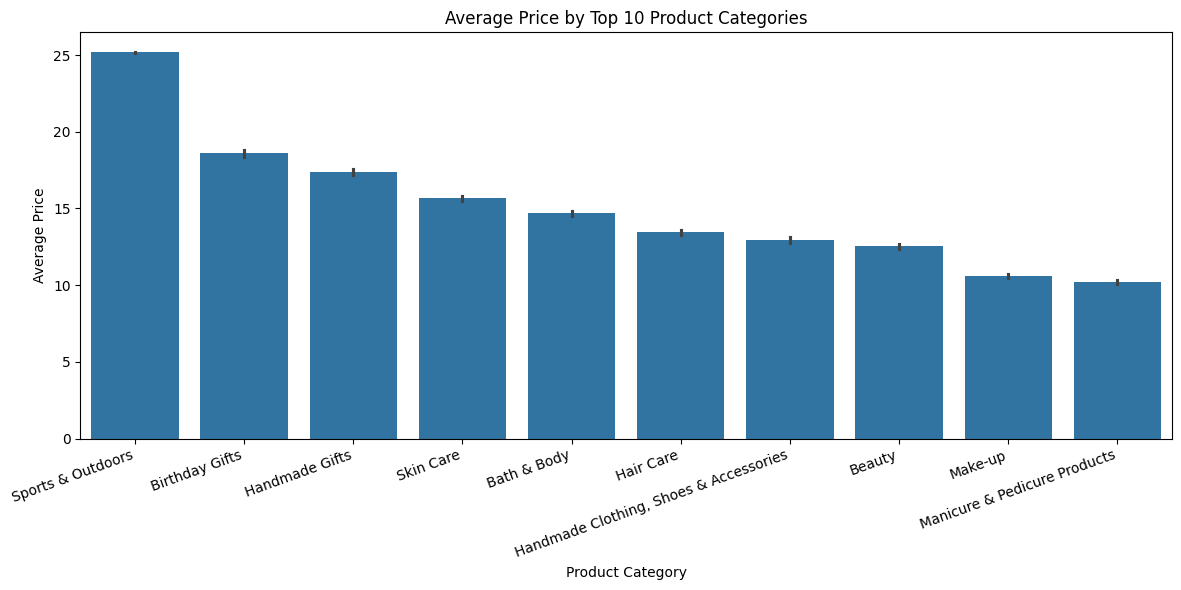

In [20]:
top_10_categories = df_no_outliers['category'].value_counts().head(10).index
avg_price_by_category = df_no_outliers[df_no_outliers['category'].isin(top_10_categories)].groupby('category')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_no_outliers[df_no_outliers['category'].isin(top_10_categories)], x='category', y='price', estimator='mean', order=avg_price_by_category.index)
plt.xticks(rotation=20, ha='right')
plt.title('Average Price by Top 10 Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

    - Which product category commands the highest average price? Don't filter here by top categories.


In [21]:
print(avg_price_by_category)
print(f"\nCategory with highest average price: {avg_price_by_category.index[0]} (£{avg_price_by_category.iloc[0]:.2f})")

category
Sports & Outdoors                         25.172065
Birthday Gifts                            18.600195
Handmade Gifts                            17.395112
Skin Care                                 15.654722
Bath & Body                               14.678683
Hair Care                                 13.461408
Handmade Clothing, Shoes & Accessories    12.958639
Beauty                                    12.523480
Make-up                                   10.612918
Manicure & Pedicure Products              10.231825
Name: price, dtype: float64

Category with highest average price: Sports & Outdoors (£25.17)



3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.


<class 'pandas.DataFrame'>
Index: 1006640 entries, 82163 to 2437154
Data columns (total 9 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   uid                1006640 non-null  int64  
 1   asin               1006640 non-null  str    
 2   title              1006640 non-null  str    
 3   stars              1006640 non-null  float64
 4   reviews            1006640 non-null  int64  
 5   price              1006640 non-null  float64
 6   isBestSeller       1006640 non-null  bool   
 7   boughtInLastMonth  1006640 non-null  int64  
 8   category           1006640 non-null  str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 70.1 MB


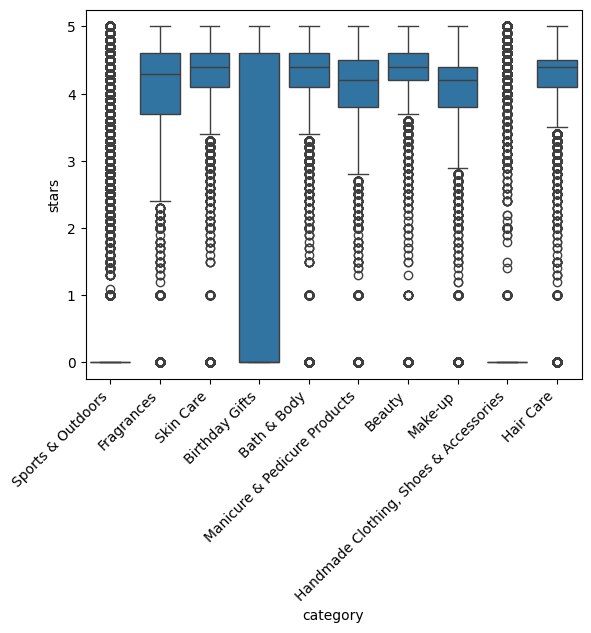

In [28]:
ht = (df['category'].value_counts().head(10).index.to_list())
htdf = df[df['category'].isin(ht)]
htdf.info()
sns.boxplot(data=htdf,x='category',y='stars')
import matplotlib.pyplot as plt
plt.xticks(rotation=45, ha='right')
plt.show()


---

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.


In [26]:
corr_price_stars = df_no_outliers['price'].corr(df_no_outliers['stars'])
print(f"Correlation price / stars: {corr_price_stars:.4f}")

Correlation price / stars: -0.0777


    - Is there a significant correlation between product price and its rating?
	


correlation almoast 0 is poor correlation

2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?


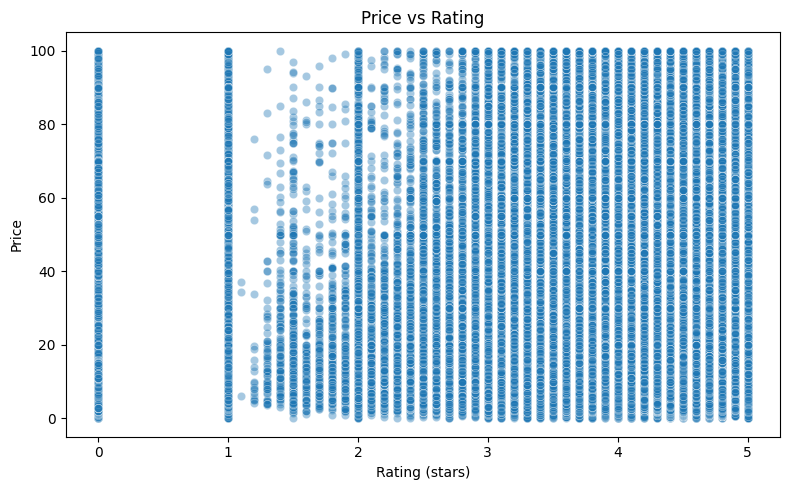

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_no_outliers, x='stars', y='price', alpha=0.4)
plt.title('Price vs Rating')
plt.xlabel('Rating (stars)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

    - Use a correlation heatmap to visualize correlations between all numerical variables.


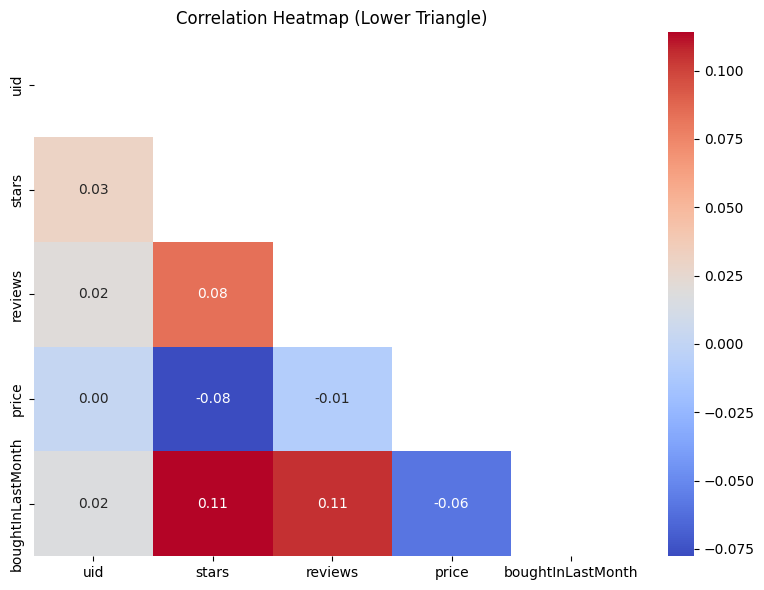

In [24]:
numeric_cols = df_no_outliers.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', mask=mask)
plt.title('Correlation Heatmap (Lower Triangle)')
plt.tight_layout()
plt.show()

    - Examine if product prices typically follow a normal distribution using a QQ plot. 


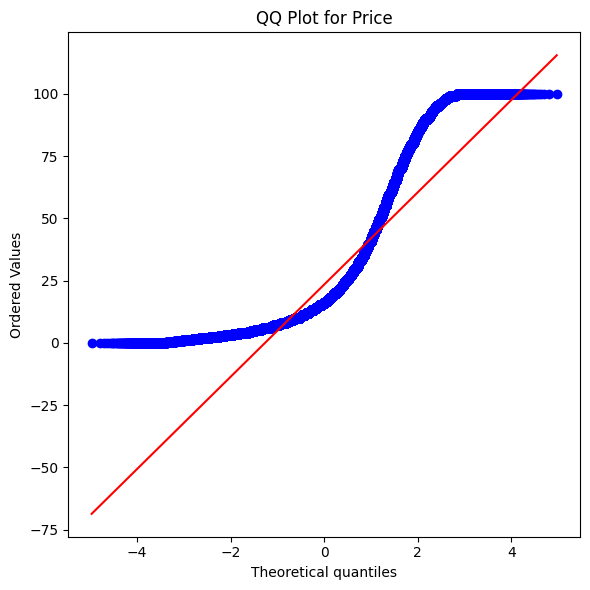

In [25]:
plt.figure(figsize=(6, 6))
probplot(df_no_outliers['price'], dist='norm', plot=plt)
plt.title('QQ Plot for Price')
plt.tight_layout()
plt.show()


---

**Submission**: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings. 

**Bonus**: 

- Do the same analysis without taking out the outliers. What are your insights?

